In [1]:
from langgraph.graph import StateGraph,START,MessagesState
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.checkpoint.postgres import PostgresSaver
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from langchain_core.messages import HumanMessage,RemoveMessage

d:\Langgraph\myenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
load_dotenv()

True

In [6]:
model = ChatGroq(model="openai/gpt-oss-120b")

In [8]:
class ChatState(MessagesState):
    summary: str

In [10]:
def chat_node(state:ChatState):
    messages =[]
    if state['summary']:
        messages.append({
            'role':'system',
            'content':f"Conversation summay:\n{state['summary']}"
        })
    
    messages.extend(state['messages'])
    print(messages)

    response=model.invoke(messages)
    return{'messages':[response]}

In [13]:
def summarize_conversation(state:ChatState):
    existing_summary=state['summary']

    # build summarization prompt
    if existing_summary:
        prompt=(
            f"existing summary:\n{existing_summary}\n\n"
            'extend the summary using the new conversation above'
        )
    else:
        prompt='summarize the above conversation'

    messages_for_summary=state['messages']+[HumanMessage(content=prompt)]

    response=model.invoke(message_for_summary)

    # keep only last 2 message
    messages_to_delete=state['messages'][:-2]

    return{
        'summary':response.content,
        'messages':[RemoveMessage(id=m.id) for m in messages_to_delete],
    }

In [11]:
def should_summarize(state:ChatState):
    return len(state['messages'])>6



In [15]:
builder=StateGraph(ChatState)

builder.add_node('chat',chat_node)
builder.add_node('summarize',summarize_conversation)

builder.add_edge(START,'chat')

builder.add_conditional_edges(
    'chat',should_summarize,
    {
        True:'summarize',
        False:'__end__'
    }
)

builder.add_edge('summarize','__end__')

In [16]:
checkpointer=InMemorySaver()
graph=builder.compile(checkpointer=checkpointer)


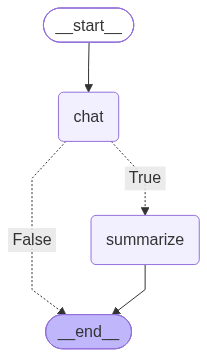

In [17]:
graph

In [18]:
config={'configurable':{'thread_id':'t1'}}

In [19]:
# gives  current versiuon of state
def show_state():
    snap= graph.get_state(config)
    vals=snap.values
    print("\n-- STATE --") 
    print('summary',vals.get('summary',""))
    print('num_messages:',len(vals.get('messages',[])))
    print('messages:')

    for m in vals.get('messages',[]):
        print("-",type(m).__name__,':',m.content[:80])

In [ ]:
out=graph.invoke({'messages':[HumanMessage(content='Quantum Physics')],'summary':''},config=config)
print(out)
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='889b3377-84d2-4ce9-a511-de8e455e8bdd')]
{'messages': [HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='889b3377-84d2-4ce9-a511-de8e455e8bdd'), AIMessage(content='Sure! Quantum physics (or quantum mechanics) is the branch of physics that describes the behavior of matter and energy at the smallest scales—typically atoms, electrons, photons, and other sub‑atomic particles. At these scales, the rules are quite different from the everyday “classical” physics we experience. Below is a concise overview of the key ideas, how they differ from classical intuition, and why they matter.\n\n---\n\n## 1. Core Principles\n\n| Principle | Classical View | Quantum View | What It Means |\n|-----------|----------------|--------------|---------------|\n| **Wave‑Particle Duality** | Particles are point‑like; waves are continuous disturbances (e.g., sound, water). | Entities like e

In [21]:
out=graph.invoke({'messages':[HumanMessage(content='how elbert einstein is related to it?')],'summary':''},config=config)
print(out)
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='889b3377-84d2-4ce9-a511-de8e455e8bdd'), AIMessage(content='Sure! Quantum physics (or quantum mechanics) is the branch of physics that describes the behavior of matter and energy at the smallest scales—typically atoms, electrons, photons, and other sub‑atomic particles. At these scales, the rules are quite different from the everyday “classical” physics we experience. Below is a concise overview of the key ideas, how they differ from classical intuition, and why they matter.\n\n---\n\n## 1. Core Principles\n\n| Principle | Classical View | Quantum View | What It Means |\n|-----------|----------------|--------------|---------------|\n| **Wave‑Particle Duality** | Particles are point‑like; waves are continuous disturbances (e.g., sound, water). | Entities like electrons and photons exhibit both particle‑like and wave‑like properties. | An electron can interfere with itself in a double‑slit experiment,